<a href="https://colab.research.google.com/github/MOHDVAZI4/college_labsheet_computervision/blob/main/cvlabsheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748.png


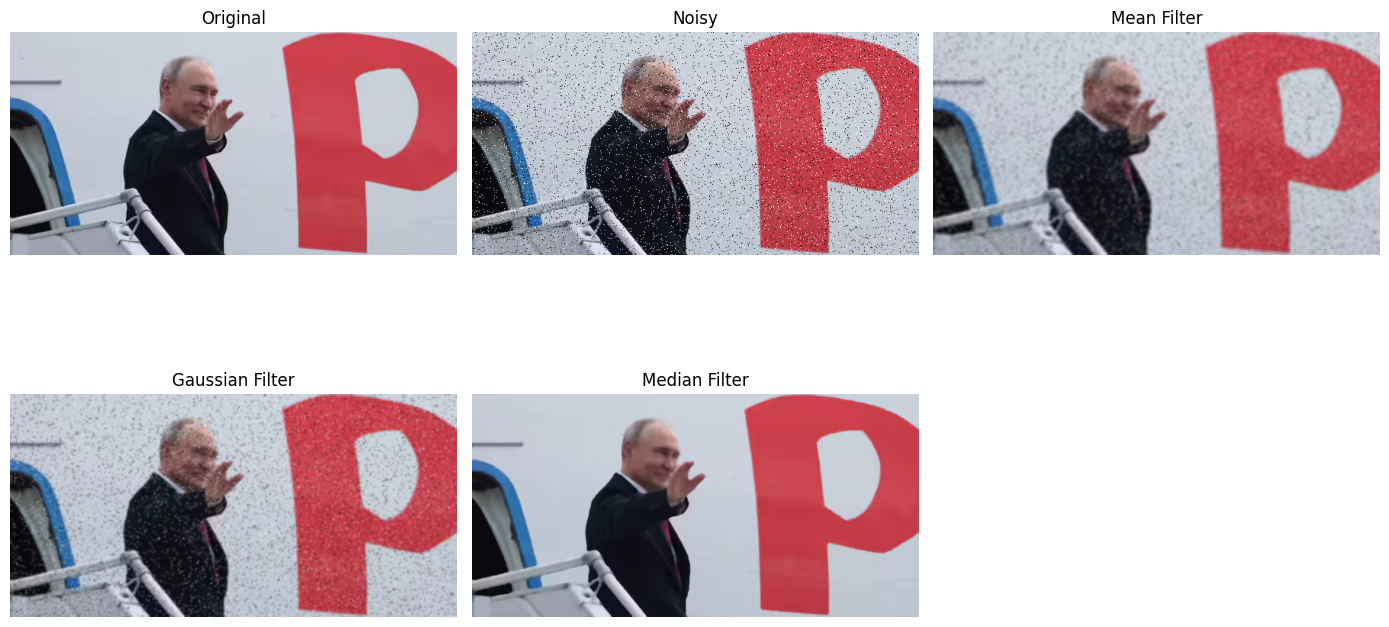

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = next(iter(uploaded))

# Read image
img = cv2.imread(filename)

if img is None:
    raise FileNotFoundError("Unable to read the uploaded image.")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Add salt-and-pepper noise
noisy = img.copy()
noise = np.random.random(img.shape[:2])

noisy[noise < 0.03] = 0
noisy[noise > 0.97] = 255

# Apply filters
mean = cv2.blur(noisy, (5, 5))
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)

# Display results
images = [img, noisy, mean, gaussian, median]
titles = [
    "Original",
    "Noisy",
    "Mean Filter",
    "Gaussian Filter",
    "Median Filter"
]

plt.figure(figsize=(14, 8))

for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (1).png


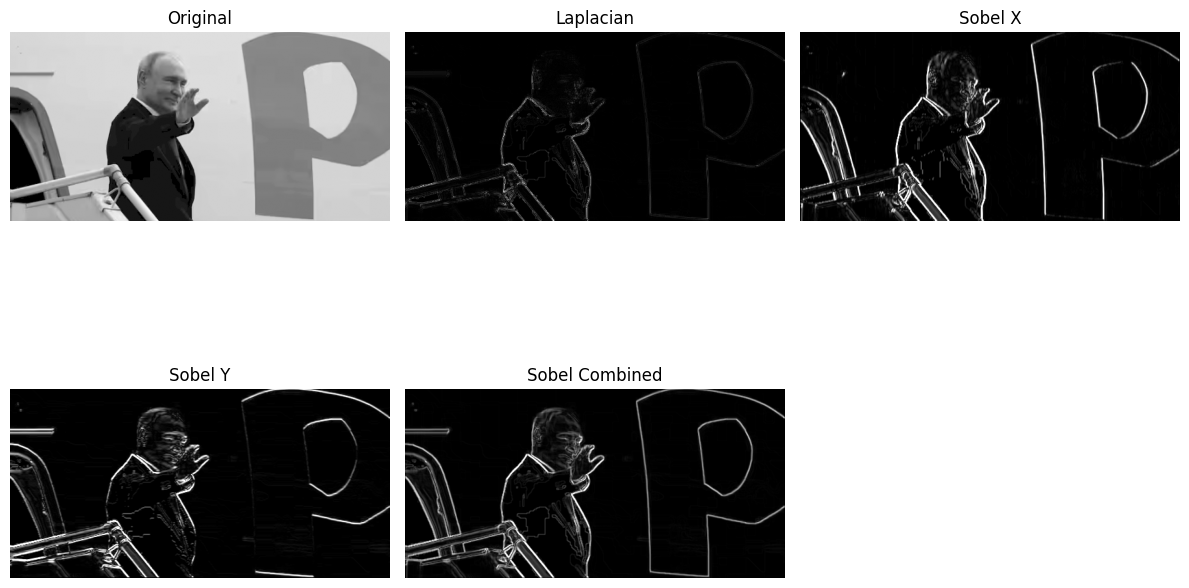

In [4]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Unable to read image")

# Laplacian filter
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Sobel filters
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

sobel = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

images = [img, laplacian, sobel_x, sobel_y, sobel]
titles = ["Original", "Laplacian", "Sobel X", "Sobel Y", "Sobel Combined"]

plt.figure(figsize=(12, 8))

for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (9).png
Enter odd kernel size (3, 5, 7, 9): 5


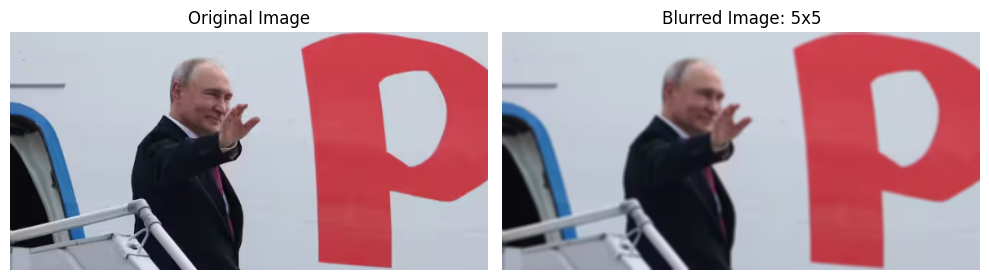

In [12]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

kernel_size = int(input("Enter odd kernel size (3, 5, 7, 9): "))

if kernel_size < 1 or kernel_size % 2 == 0:
    raise ValueError("Kernel size must be a positive odd number")

blurred = cv2.blur(img, (kernel_size, kernel_size))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title(f"Blurred Image: {kernel_size}x{kernel_size}")
plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (3).png


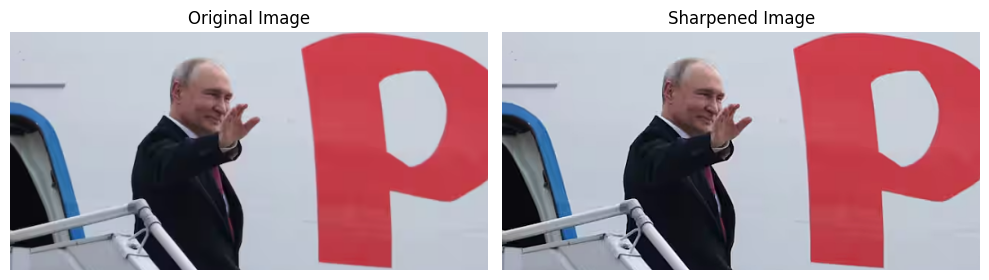

In [6]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply Gaussian blur
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Unsharp masking
sharpened = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gaussian = cv2.GaussianBlur(img, (9, 9), 0)

bilateral = cv2.bilateralFilter(
    img, 9, 75, 75
)

images = [img, gaussian, bilateral]
titles = ["Original", "Gaussian Blur", "Bilateral Filter"]

plt.figure(figsize=(12, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (8).png


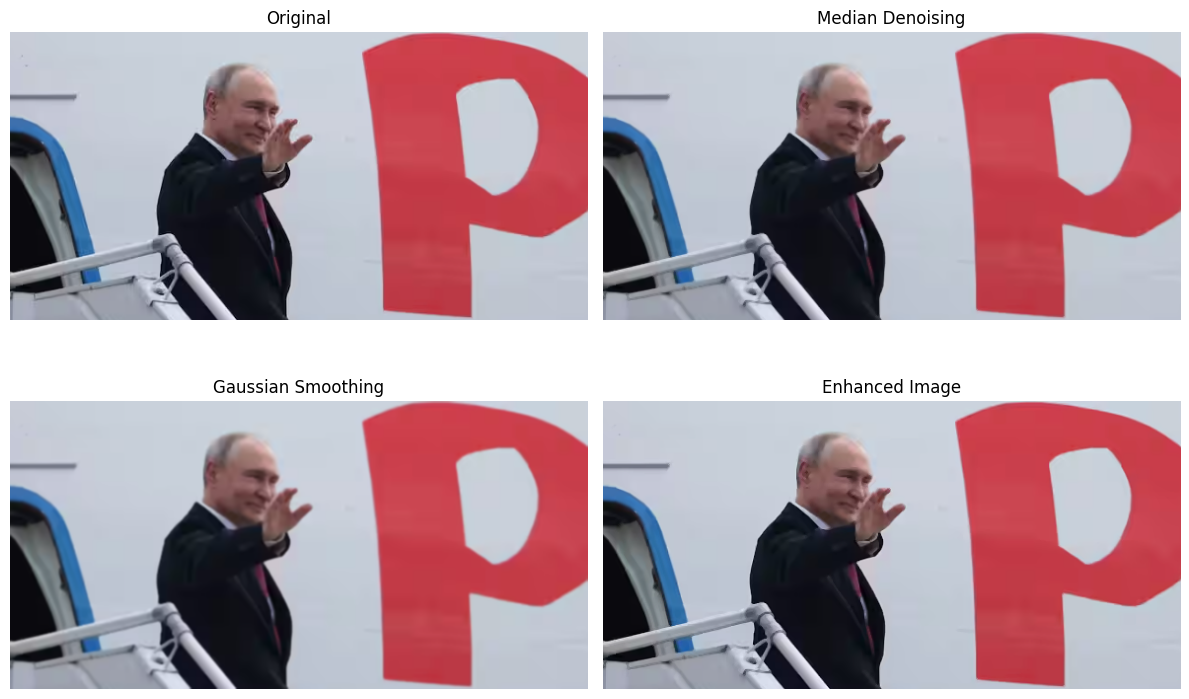

In [11]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Remove noise
denoised = cv2.medianBlur(img, 3)

# Smooth the image
smooth = cv2.GaussianBlur(denoised, (3, 3), 0)

# Enhance details
result = cv2.addWeighted(denoised, 1.5, smooth, -0.5, 0)

images = [img, denoised, smooth, result]
titles = ["Original", "Median Denoising", "Gaussian Smoothing", "Enhanced Image"]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (7).png


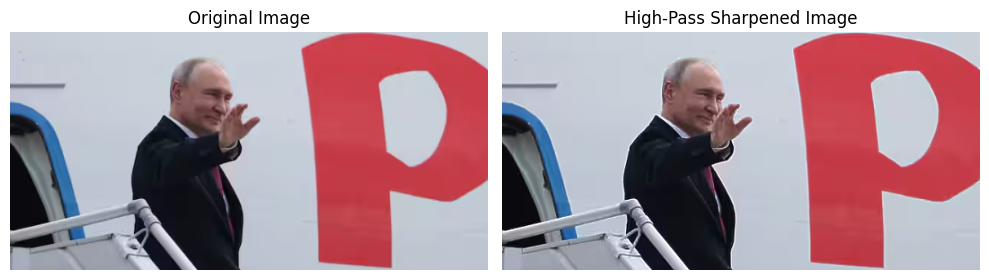

In [10]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply high-pass sharpening
blurred = cv2.GaussianBlur(img, (5, 5), 0)
high_pass = cv2.subtract(img, blurred)
sharpened = cv2.addWeighted(img, 1.0, high_pass, 1.5, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title("High-Pass Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (6).png


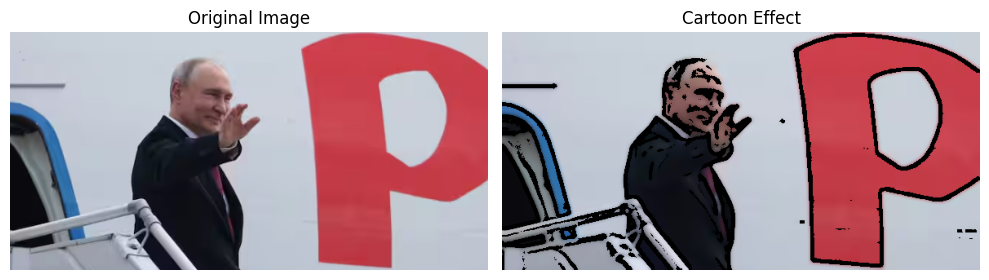

In [9]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Smooth colors
smooth = cv2.bilateralFilter(img, 9, 250, 250)

# Detect edges
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.medianBlur(gray, 7)

edges = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9, 2
)

# Combine smooth colors with edges
cartoon = cv2.bitwise_and(smooth, smooth, mask=edges)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cartoon)
plt.title("Cartoon Effect")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Add salt-and-pepper noise
noisy = img.copy()
noise = np.random.random(img.shape[:2])

noisy[noise < 0.03] = 0
noisy[noise > 0.97] = 255

# Apply filters
mean = cv2.blur(noisy, (5, 5))
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)
bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

filters = {
    "Noisy": noisy,
    "Mean": mean,
    "Gaussian": gaussian,
    "Median": median,
    "Bilateral": bilateral
}

print(f"{'Filter':<12} {'PSNR':>10} {'SSIM':>10}")
print("-" * 34)

for name, result in filters.items():
    psnr = peak_signal_noise_ratio(img, result, data_range=255)
    ssim = structural_similarity(
        img, result, channel_axis=2, data_range=255
    )
    print(f"{name:<12} {psnr:>10.2f} {ssim:>10.4f}")

plt.figure(figsize=(14, 8))

images = [img] + list(filters.values())
titles = ["Original"] + list(filters.keys())

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748 (5).png
Enter the 3x3 kernel values row by row:
Row 1: 0 -1 0
Row 2: 1 -5 1
Row 3: 1 0 1


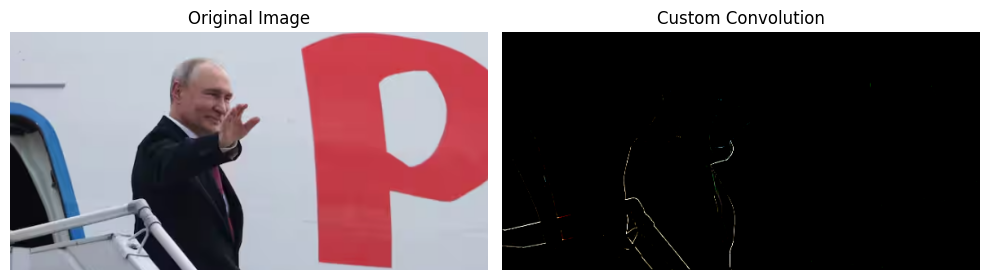

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)

if img is None:
    raise ValueError("Unable to read image")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Enter the 3x3 kernel values row by row:")

kernel = []

for i in range(3):
    row = list(map(float, input(f"Row {i+1}: ").split()))
    if len(row) != 3:
        raise ValueError("Each row must contain exactly 3 values")
    kernel.append(row)

kernel = np.array(kernel, dtype=np.float32)

result = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Custom Convolution")
plt.axis("off")

plt.tight_layout()
plt.show()